In [67]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

### 1️⃣ Data Retrieval and Collection
Load the dataset
Display basic information (shape, column names)

In [69]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df  

In [70]:
df = load_data("Salary_dataset.csv")

In [71]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344
1,1,1.4,46206
2,2,1.6,37732
3,3,2.1,43526
4,4,2.3,39892


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes


In [73]:
df.describe()


,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


### 2️⃣ Data Cleaning
Handle missing values (if any)
Explain how missing values were treated (if any)
Verify data types

In [86]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [119]:
df.drop_duplicates()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344
1,1,1.4,46206
2,2,1.6,37732
3,3,2.1,43526
4,4,2.3,39892
5,5,3.0,56643
6,6,3.1,60151
7,7,3.3,54446
8,8,3.3,64446
9,9,3.8,57190


In [130]:
df.dtypes

Unnamed: 0           int64
YearsExperience    float64
Salary               int64
dtype: object

### 3️⃣ Feature Design
Separate features (X) and label (y)

In [131]:
feature = df[['YearsExperience']]
target = df['Salary']



In [132]:
feature.head()

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3


### 4️⃣ Algorithm Selection
Choose Linear Regression
Explain why linear regression is appropriate for this task

here we use linear regression because as linear regression model is used to show relationship between dependent and two or more  independent variables by fitting a straight line that best represents the data trend,here we assume salary is directly proportional to the years of experience ,salary increases with the years of experience ina straight line . so due to overall reasons,linear regression works here because it captures and visualize the underlining relationship between salary and years of experience 

### 5️⃣ Loss Function Selection
Use Mean Squared Error (MSE)
Briefly explain what MSE measures

Here ,MSE is used as a loss function for linear regression.It measures the average of the squared differences between the actual values and the predicted values.simply, mse tells us how far the model prediction is from real salary values.It squares the errors so that larger mistakes are penalized more heavily than smaller ones. A lower MSE indicates that the model is making more accurate predictions and fitting the data better.

### 6️⃣ Model Learning (Training)
Train the linear regression model
Clearly state the learning process

### Training and testing model
hwere dataset is used to train a linear regression model so it can learn the relationship between years of experience and salary .so dataet is divided into training and testong setss.

In [133]:
x_tr, x_te, y_tr, y_te = train_test_split(feature, target, test_size=0.5, random_state=42)

In [134]:
x_tr.shape, x_te.shape, y_tr.shape, y_te.shape

((15, 1), (15, 1), (15,), (15,))

we standarize data to improve overall model performance ,converts data into standard range .(1=variance,mean=0)

In [135]:
scalar = StandardScaler()
x_tr_scaled = scalar.fit_transform(x_tr)
x_te_scaled = scalar.fit_transform(x_te)

linear regression model is created and trained as model learns relationship between experience and salary and estimate the best-fit line by minimizing the error

In [136]:
linear_model = LinearRegression()
linear_model.fit(x_tr_scaled, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[26413.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.85e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.87]


 here train model predicts the salary 

In [137]:
y_pred = linear_model.predict(x_te_scaled)

for comparision firstly the data is sorted ,purple dots -actual salary,pink line-predicted regression line,red lines-error(difference between actual and predicted value),short lines -good predictions ,longer lines-higher error

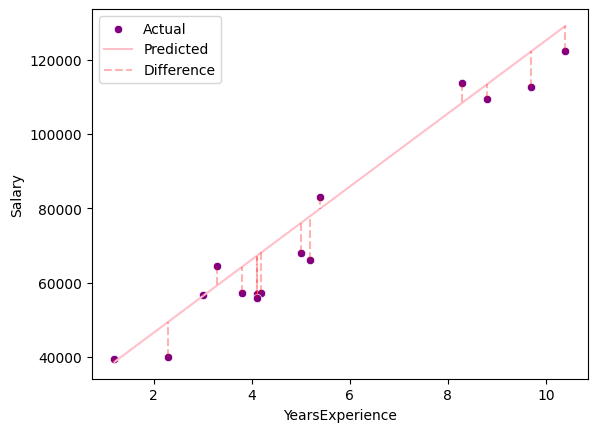

In [139]:
order = np.argsort(x_te['YearsExperience'].values)

sns.scatterplot(
    x=x_te['YearsExperience'].values,
    y=y_te.values,
    label='Actual',
    color='purple'
)

sns.lineplot(
    x=x_te['YearsExperience'].values[order],
    y=y_pred.ravel()[order],
    label='Predicted',
    color='pink'
)

plt.xlabel('YearsExperience')
plt.ylabel('Salary')

plt.vlines(
    x=x_te['YearsExperience'].values[order],
    ymin=y_te.values[order],
    ymax=y_pred.ravel()[order],
    colors='r',
    linestyles='--',
    label='Difference',
    alpha=0.3
)

plt.legend()
plt.show()

###  Model Evaluation
Report:
Mean Squared Error (MSE)
(Optional) R² Score
Provide a short interpretation of the result

In [140]:
MSE = mean_squared_error(y_true=y_te, y_pred=y_pred)
print(f"Mean Square Error: {MSE}")

Mean Square Error: 61463554.904191285


r2 simply shows or explain how well model  explain the variable in salary.here valu ranges from 0 to 1 (0=poor,1-perfecr prediction)

In [142]:
from sklearn.metrics import r2_score
r2 = r2_score(y_te, y_pred)
print("R² Score:", r2)

R² Score: 0.9146490308959933


The coefficient shows the rate of change of salary with respect to years of experience.
It tells how much salary increases when experience increases by 1 year

In [143]:
linear_model.coef_

array([26413.3539151])

The intercept is the predicted salary when Years of Experience = 0.It represents the starting salary level in the model.

In [144]:
linear_model.intercept_

np.float64(78495.93333333332)

### DISCUSSUION 

As lab works helps us to increase our practical knowledge ,here we learn about the linear regression model.we use salary datasets which includes years of experience and salary.we use linear regression model because we assume that salary and years of experience is directly proportional to each other,as years of experience is higher the salary is also high .we trained ;inear regression model to predict salafy based on the years of experience .The coefficient shows the rate of change of salary with respect to years of experience.
It tells how much salary increases when experience increases by 1 year.The intercept is the predicted salary when Years of Experience = 0.It represents the starting salary level in the model.Here ,MSE is used as a loss function for linear regression.It measures the average of the squared differences between the actual values and the predicted values.simply, mse tells us how far the model prediction is from real salary values.It squares the errors so that larger mistakes are penalized more heavily than smaller ones. A lower MSE indicates that the model is making more accurate predictions and fitting the data better.r2 simply shows or explain how well model  explain the variable in salary.here valu ranges from 0 to 1 (0=poor,1-perfecr prediction)

### CONCLUSION 

Lastly,we met the main objective of this practical ,the Linear Regression model successfully captures the relationship between years of experience and salary. The coefficient confirms that 
salary increases with experience, while the intercept represents the baseline salary when experience is zero.